ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [3]:
# Load Dataset

df = pd.read_csv(
    '/content/online_retail.csv',
    encoding='latin1')

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Check Missing Values

In [4]:
# Check all values
print(df.isna())

        InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  \
0           False      False        False     False        False      False   
1           False      False        False     False        False      False   
2           False      False        False     False        False      False   
3           False      False        False     False        False      False   
4           False      False        False     False        False      False   
...           ...        ...          ...       ...          ...        ...   
541904      False      False        False     False        False      False   
541905      False      False        False     False        False      False   
541906      False      False        False     False        False      False   
541907      False      False        False     False        False      False   
541908      False      False        False     False        False      False   

        CustomerID  Country  
0            False   

In [5]:
print(df.isna().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### Check duplicate rows

In [6]:
# checking duplicate rows
df.duplicated().sum()

np.int64(5268)

### No. of rows and columns

In [7]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (541909, 8) 

number of rows:  541909
number of columns:  8


### Data type of columns

In [8]:
# viewing the data types of columns
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [10]:
# Statistical summary
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,NaN,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [12]:
# BEFORE CLEANING
df.shape

(541909, 8)

In [13]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

The dataset contains retail transaction records with columns such as InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country. The dataset was inspected using df.info(), df.shape, and df.describe() to understand its structure, data types, and summary statistics.

Data Cleaning

In [15]:
# Handle missing values
# to remove rows where CustomerID and Description are missing

df = df.dropna(subset=['CustomerID'])
df = df.dropna(subset=['Description'])



In [16]:
# Handle Duplicates
df = df.drop_duplicates()

In [ ]:
# reset index (clean look)

df = df.reset_index(drop=True)



In [18]:
# After Cleaning (no duplicates and missing values anymore)

df.isna().sum()


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [19]:
df.duplicated().sum()


np.int64(0)

In [22]:
# To fix incorrect format

df['CustomerID'] = df['CustomerID'].astype(int)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [23]:
# Remove Negative values

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [24]:
# After Cleaning

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


In [25]:
#AFTER CLEANING

df.shape

(392692, 8)

The dataset contained missing values in the "Description" and "CustomerID" columns, which were removed to improve data quality. Additionally, duplicate rows were identified and removed. The dataset also contained incorrect and unrealistic values, such as negative quantities and unit prices, which were filtered out since they are not valid in a retail context. After cleaning, the dataset became more consistent, accurate, and suitable for analysis.

The number of rows decreased from 541,909 to 392,692 after cleaning, indicating that invalid and duplicate records were successfully removed.

## Data Visualization and Insights



plot 1 - Top Countries

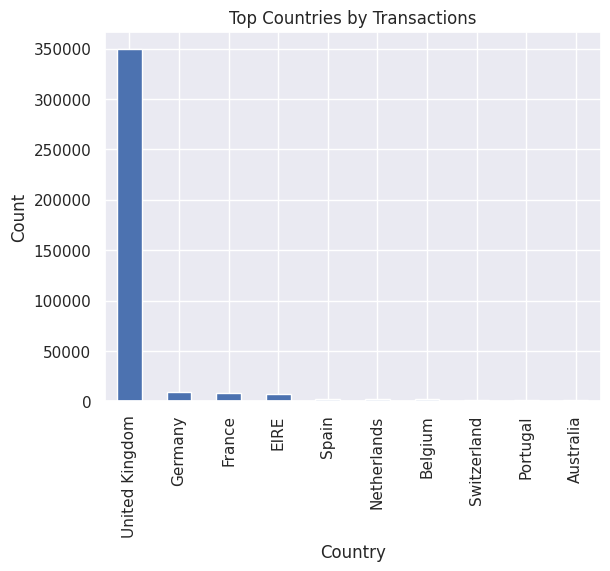

In [26]:
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top Countries by Transactions')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()


This bar chart shows the top countries based on number of transactions. It was chosen to identify which countries contribute most to the dataset. The chart shows that the United Kingdom has the highest number of transactions.

Plot 2 - Quantity Distribution

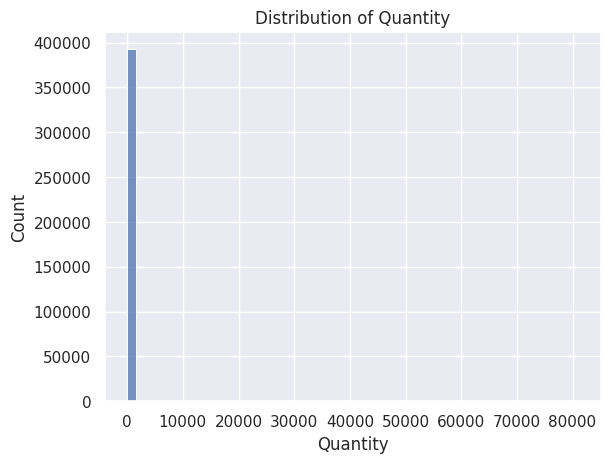

In [31]:
sns.histplot(df['Quantity'], bins=50)
plt.title('Distribution of Quantity')
plt.show()

This histogram shows the distribution of quantities before removing extreme values. The presence of outliers causes the distribution to appear highly skewed and difficult to interpret.


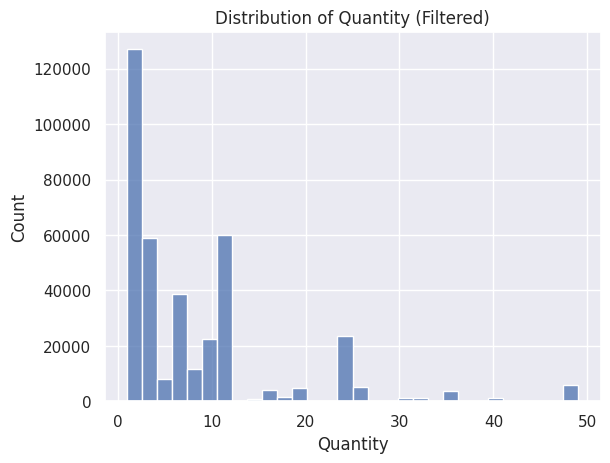

In [30]:
df_filtered = df[(df['Quantity'] > 0) & (df['Quantity'] < 50)]
plt.show()

After removing extreme values, the distribution becomes clearer. Most transactions involve small quantities, while large purchases are rare.

plot 3 - Unit Price Distribution


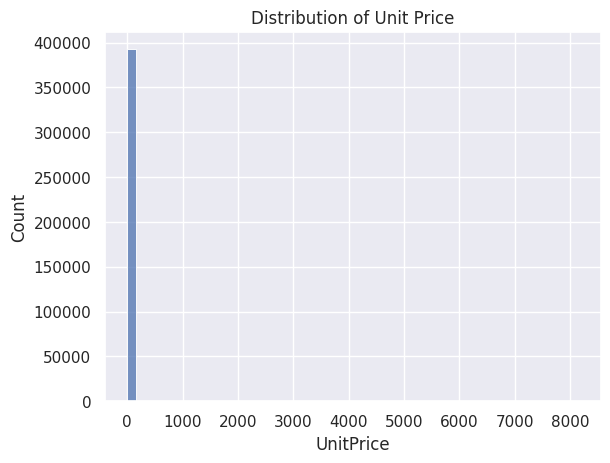

In [28]:
sns.histplot(df['UnitPrice'], bins=50)
plt.title('Distribution of Unit Price')
plt.show()

This histogram shows the distribution of unit prices before removing extreme values. The presence of very high prices causes the data to be highly skewed and difficult to interpret.

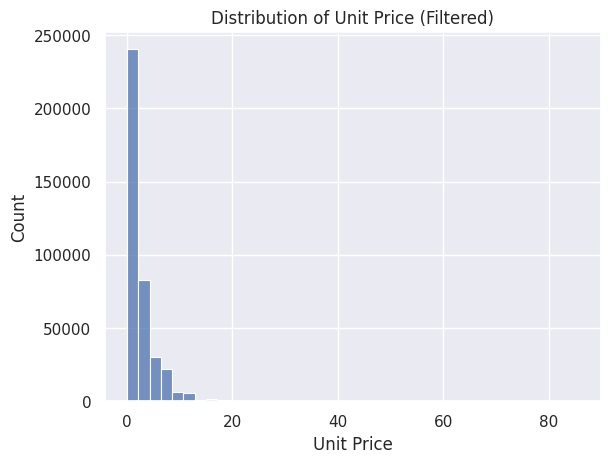

In [32]:
df_price = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] < 100)]

sns.histplot(df_price['UnitPrice'], bins=40)
plt.title('Distribution of Unit Price (Filtered)')
plt.xlabel('Unit Price')
plt.ylabel('Count')
plt.show()

After filtering unrealistic values, the distribution becomes clearer. Most products have low prices, while higher prices are less common.

Plot 4 - Quantity vs price

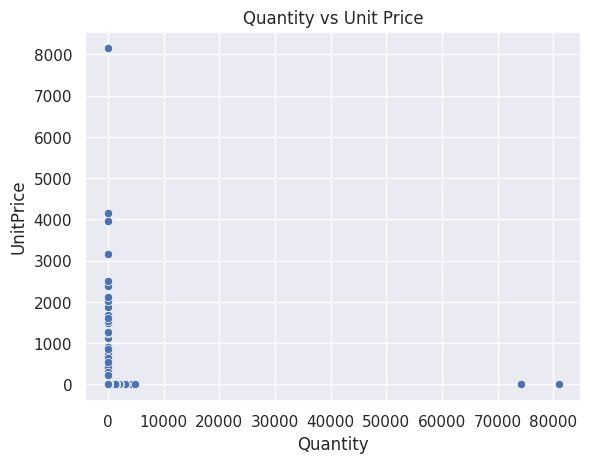

In [33]:
sns.scatterplot(x='Quantity', y='UnitPrice', data=df)
plt.title('Quantity vs Unit Price')
plt.show()

This scatter plot shows the relationship between quantity and unit price before removing outliers. The presence of extreme values makes it difficult to observe any clear pattern.

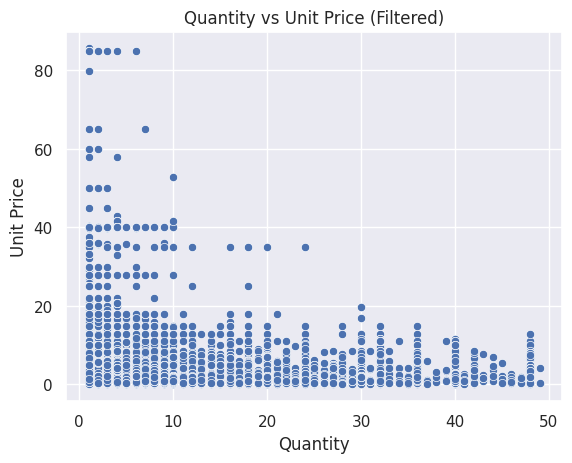

In [34]:
df_clean = df[
    (df['Quantity'] > 0) & (df['Quantity'] < 50) &
    (df['UnitPrice'] > 0) & (df['UnitPrice'] < 100)
]

sns.scatterplot(x='Quantity', y='UnitPrice', data=df_clean)
plt.title('Quantity vs Unit Price (Filtered)')
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.show()

After removing extreme values, the relationship becomes clearer. There is no strong correlation between quantity and unit price, indicating that price does not depend heavily on the quantity purchased.

plot 5 - Top Products

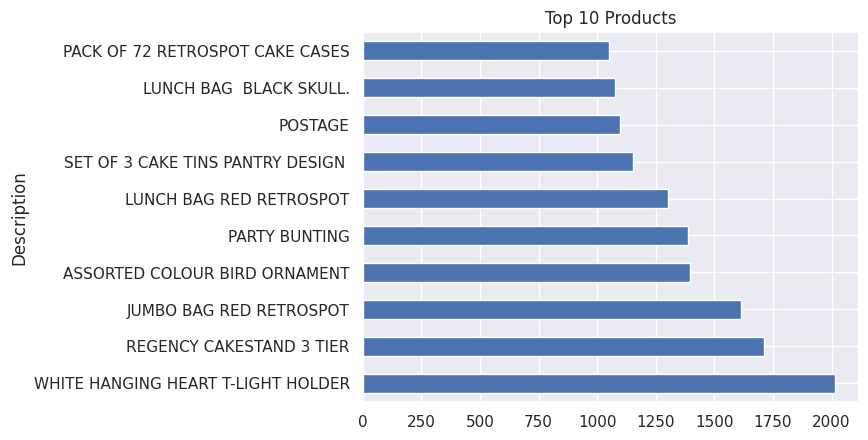

In [35]:
df['Description'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Products')
plt.show()

This chart shows the most frequently purchased products. It helps identify popular items. Some products appear significantly more often than others, indicating high demand.

Plot 6 - Monthly Trend


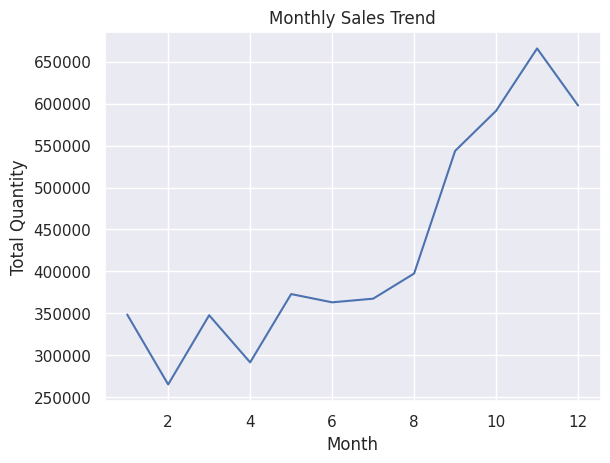

In [36]:
df['Month'] = df['InvoiceDate'].dt.month

df.groupby('Month')['Quantity'].sum().plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Quantity')
plt.show()

This line chart shows sales trends over months. It was chosen to identify seasonal patterns. The data indicates variations in sales across different months.

plot 7 - boxplot (outliers)

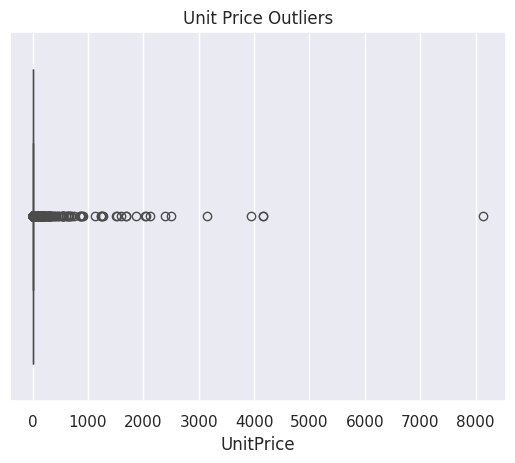

In [37]:
sns.boxplot(x=df['UnitPrice'])
plt.title('Unit Price Outliers')
plt.show()

This boxplot identifies outliers in unit prices. It shows that while most prices are low, there are some extreme values that are significantly higher.



plot 8 - Correlation

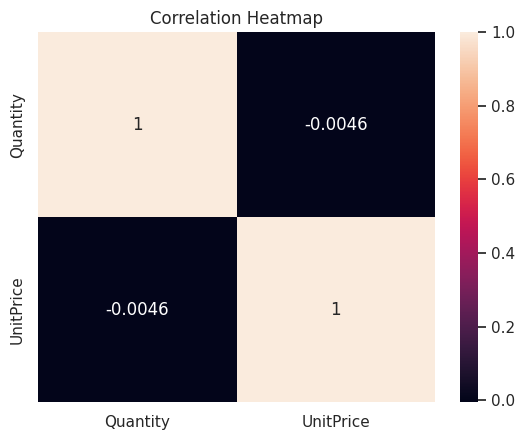

In [38]:
sns.heatmap(df[['Quantity','UnitPrice']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

This heatmap shows the correlation between numerical variables. It helps identify relationships between features. The correlation between quantity and unit price appears to be weak.

Final Insights

The analysis shows that most transactions come from the United Kingdom. The dataset contains a wide range of product quantities and prices, with most values concentrated at lower levels. Some products are significantly more popular than others. There are also noticeable outliers in unit prices. Overall, the dataset reveals important patterns in customer purchasing behavior and product demand.

Most orders come from a few countries, showing that sales are concentrated in specific regions.


# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
